In [ ]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import os
import re
import numpy as np

%matplotlib inline
%config InlineBackend.figure_format='retina'

In [ ]:
measurements_path = "../measurements"
possible_files = np.sort(os.listdir(measurements_path))
possible_files

result = []
for my_file in possible_files:
    prefix = re.sub("__measurements.*", "", my_file)
    temp = pd.read_csv(os.path.join(measurements_path, my_file), index_col = 0)
    adata_temp = sc.AnnData(temp)
    adata_temp.obs_names = [prefix + "__" + x for x in adata_temp.obs_names]
    result.append(adata_temp)

In [ ]:
adata_main = sc.concat(result, join='outer', fill_value=0)
adata_CC3 = sc.concat(result_cc3, join='outer', fill_value=0)
adata_CPA1 = sc.concat(result_CPA1, join='outer', fill_value=0)

In [ ]:
adata_final = sc.concat([adata_main,adata_CC3,adata_CPA1], axis = 'var')

In [ ]:
adata_final.obs['slide_id'] = [re.findall('(.*?)__', x)[0] for x in adata_final.obs_names]

In [ ]:
X_spatial = np.array(adata_final[:,['centroid_row', 'centroid_col']].X)
adata_final.obsm['X_spatial'] = X_spatial.copy()

In [ ]:
selected_columns = [
    'cyto_area', 'cyto_solidity',
    'nucleus_area', 'nucleus_solidity',
    'centroid_row', 'centroid_col'
]
df = pd.DataFrame(adata_final[:,selected_columns].X, index = adata_final.obs_names, columns = selected_columns)
for my_column in df.columns:
    adata_final.obs[my_column] = df[my_column].copy()
    

In [ ]:
adata_final = adata_final[:,np.logical_not(np.isin(adata_final.var_names, selected_columns))].copy()

In [ ]:
adata_sub = adata_final[adata_final.obs['slide_id'] == 'JR-sp-40-11',:].copy()

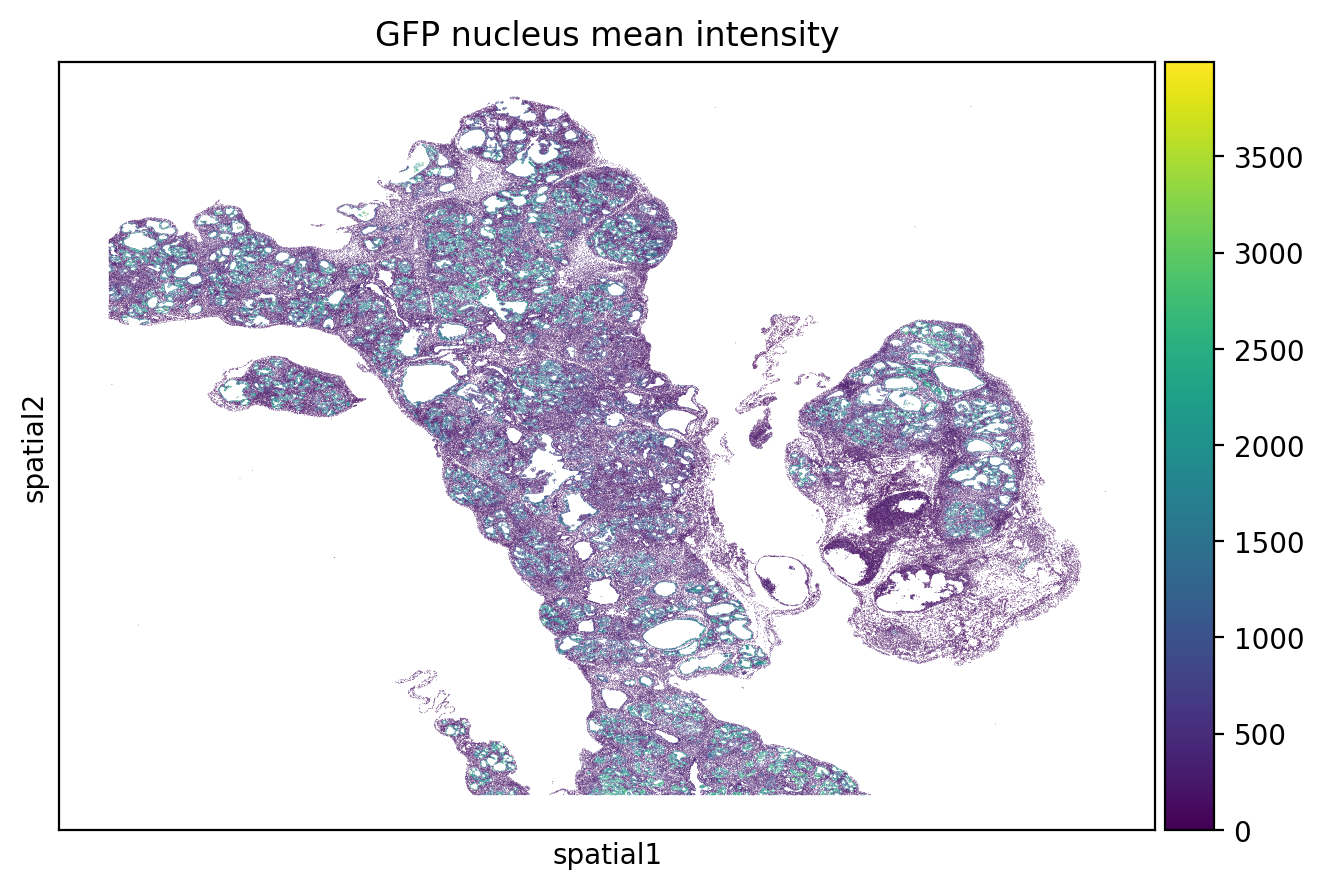

In [ ]:
sc.pl.scatter(adata_sub, basis='spatial', color = 'GFP_nucleus_mean_intensity')

In [ ]:
sc.write("../preprocessed/Reyes_COMET_Krasi4h_adata_04_all_samples.h5ad", adata=adata_final)